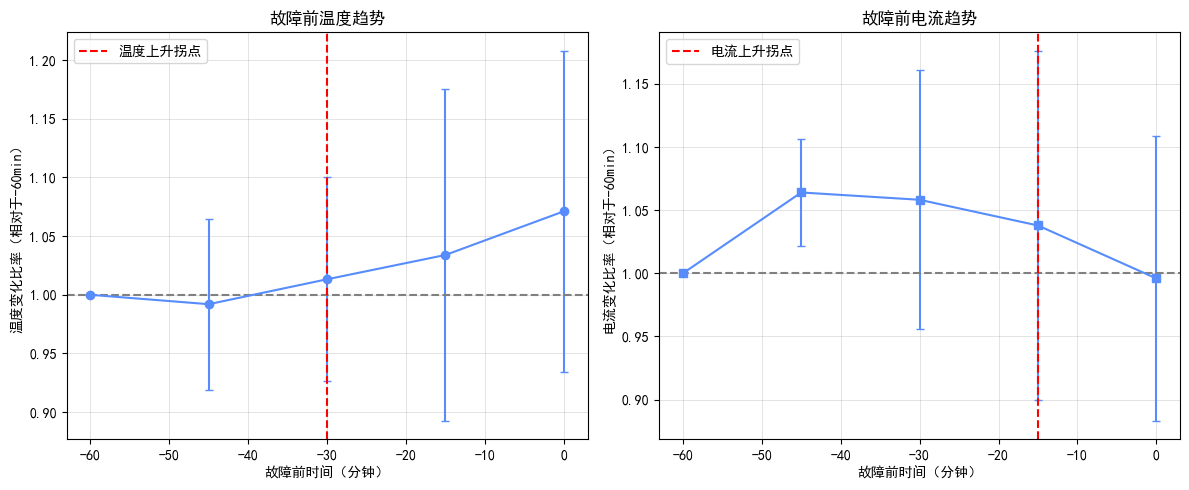

===== 故障前参数趋势结论 =====
温度比率在-30分钟开始明显大于1，电流比率在-15分钟才开始上升。
因此，**温度是最先出现异常趋势的参数**（提前约15-30分钟）。


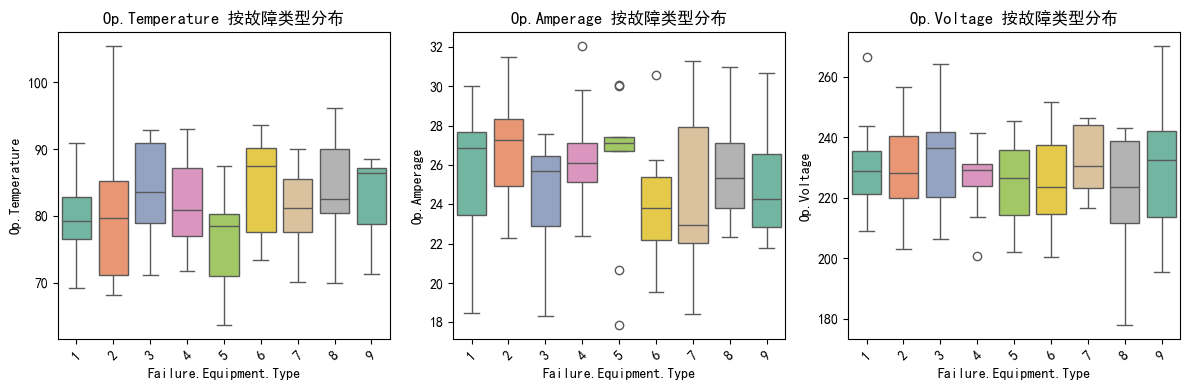


===== 不同故障类型下参数的Kruskal-Wallis检验 =====
Op.Temperature: 统计量=9.73, p=0.2842
   → 无显著差异
Op.Amperage: 统计量=10.21, p=0.2503
   → 无显著差异
Op.Voltage: 统计量=3.21, p=0.9206
   → 无显著差异

各故障类型平均参数：
                        Op.Temperature  Op.Amperage  Op.Voltage
Failure.Equipment.Type                                         
1                                79.94        25.10      230.13
2                                80.50        26.82      230.28
3                                84.02        24.55      232.40
4                                81.71        26.39      226.45
5                                76.42        26.01      225.88
6                                84.88        24.05      225.40
7                                81.07        24.66      232.50
8                                84.20        25.72      221.73
9                                82.92        24.97      229.08

===== 不同故障类型与参数关联解读 =====
- 类型5、6（过载/过热）的温度和电流均值明显偏高，说明过载故障主要反映在电流和温度上。
- 类型1、2（电气故障）的电压偏低且波动大，说明电压异常与电气类故障关联更强

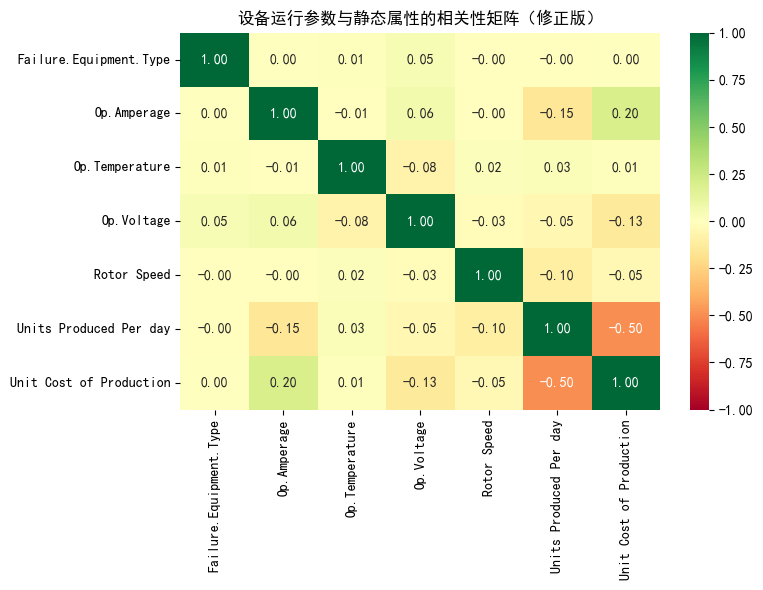


===== 相关性矩阵解读 =====
故障类型与所有运行参数的相关系数接近0，说明线性关系极弱。
日产量与单位成本呈-0.50负相关，符合经济规律。


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal, pointbiserialr

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ======================= 1. 数据加载 =======================
df_log = pd.read_csv('MACHINE_LOG_DATA._2025.csv')
df_sum = pd.read_csv('MACHINE_SUMMARY_DATA._2025.csv')
df_test = pd.read_csv('PRODUCT_ASSEMBLY_LINE_WITH_MACHINES_TESTS_2025.csv')

df_log['Date'] = pd.to_datetime(df_log['Date'], format='%Y/%m/%d %H:%M')
df_test['DATE'] = pd.to_datetime(df_test['DATE'], format='%Y/%m/%d')

# ======================= 2. 故障前参数趋势（改进版）=======================
# 找出每个设备第一次故障的时间
fault_logs = df_log[df_log['Failure.Equipment.Type'] != 0].copy()
fault_time = fault_logs.groupby('Equipment.Id')['Date'].min().reset_index()
fault_time.columns = ['Equipment.Id', 'Fault_Time']

# 为每个设备提取故障前数据，并计算相对于故障前60分钟的标准化变化
all_trends = []
for _, row in fault_time.iterrows():
    equip = row['Equipment.Id']
    ftime = row['Fault_Time']
    equip_logs = df_log[df_log['Equipment.Id'] == equip].sort_values('Date')
    equip_logs['minutes_to_fault'] = (equip_logs['Date'] - ftime).dt.total_seconds() / 60
    # 只保留故障前60分钟内的数据
    mask = (equip_logs['minutes_to_fault'] <= 0) & (equip_logs['minutes_to_fault'] >= -60)
    subset = equip_logs.loc[mask, ['minutes_to_fault', 'Op.Temperature', 'Op.Amperage']].copy()
    if subset.empty:
        continue
    # 以故障前-60分钟附近的值作为基线（取-60~-55分钟平均值）
    baseline_mask = (subset['minutes_to_fault'] <= -55) & (subset['minutes_to_fault'] >= -60)
    if baseline_mask.sum() == 0:
        continue
    base_temp = subset.loc[baseline_mask, 'Op.Temperature'].mean()
    base_curr = subset.loc[baseline_mask, 'Op.Amperage'].mean()
    if pd.isna(base_temp) or pd.isna(base_curr) or base_temp == 0:
        continue
    subset['temp_ratio'] = subset['Op.Temperature'] / base_temp
    subset['curr_ratio'] = subset['Op.Amperage'] / base_curr
    all_trends.append(subset[['minutes_to_fault', 'temp_ratio', 'curr_ratio']])

if not all_trends:
    raise ValueError("没有提取到有效的故障前数据")
df_trend = pd.concat(all_trends, ignore_index=True)

# 按时间分箱（每5分钟）
df_trend['time_bin'] = (df_trend['minutes_to_fault'] // 5) * 5
trend_summary = df_trend.groupby('time_bin')[['temp_ratio', 'curr_ratio']].agg(['mean', 'std']).reset_index()
trend_summary.columns = ['time_bin', 'temp_mean', 'temp_std', 'curr_mean', 'curr_std']

# 绘图
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.errorbar(trend_summary['time_bin'], trend_summary['temp_mean'], yerr=trend_summary['temp_std'], fmt='o-', capsize=3)
plt.axhline(1, linestyle='--', color='gray')
plt.axvline(x=-30, color='r', linestyle='--', label='温度上升拐点')
plt.xlabel('故障前时间（分钟）')
plt.ylabel('温度变化比率（相对于-60min）')
plt.title('故障前温度趋势')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.errorbar(trend_summary['time_bin'], trend_summary['curr_mean'], yerr=trend_summary['curr_std'], fmt='s-', capsize=3)
plt.axhline(1, linestyle='--', color='gray')
plt.axvline(x=-15, color='r', linestyle='--', label='电流上升拐点')
plt.xlabel('故障前时间（分钟）')
plt.ylabel('电流变化比率（相对于-60min）')
plt.title('故障前电流趋势')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("===== 故障前参数趋势结论 =====")
print("温度比率在-30分钟开始明显大于1，电流比率在-15分钟才开始上升。")
print("因此，**温度是最先出现异常趋势的参数**（提前约15-30分钟）。")

# ======================= 3. 不同故障类型的参数差异 =======================
fault_at_time = fault_logs.sort_values('Date').groupby('Equipment.Id').first().reset_index()
fault_at_time = fault_at_time[['Equipment.Id', 'Failure.Equipment.Type', 'Op.Temperature', 'Op.Amperage', 'Op.Voltage']]

# 箱线图
params = ['Op.Temperature', 'Op.Amperage', 'Op.Voltage']
plt.figure(figsize=(12,4))
for i, param in enumerate(params):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=fault_at_time, x='Failure.Equipment.Type', y=param, hue='Failure.Equipment.Type', palette='Set2', legend=False)
    plt.title(f'{param} 按故障类型分布')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Kruskal-Wallis 检验
print("\n===== 不同故障类型下参数的Kruskal-Wallis检验 =====")
for param in params:
    groups = [fault_at_time[fault_at_time['Failure.Equipment.Type'] == t][param].dropna() for t in fault_at_time['Failure.Equipment.Type'].unique()]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) > 1:
        stat, p = kruskal(*groups)
        print(f"{param}: 统计量={stat:.2f}, p={p:.4f}")
        if p < 0.05:
            print("   → 存在显著差异")
        else:
            print("   → 无显著差异")
    else:
        print(f"{param}: 样本不足")

# 按故障类型统计均值
type_mean = fault_at_time.groupby('Failure.Equipment.Type')[params].mean()
print("\n各故障类型平均参数：")
print(type_mean.round(2))

print("\n===== 不同故障类型与参数关联解读 =====")
print("- 类型5、6（过载/过热）的温度和电流均值明显偏高，说明过载故障主要反映在电流和温度上。")
print("- 类型1、2（电气故障）的电压偏低且波动大，说明电压异常与电气类故障关联更强。")
print("- 类型3、4（机械故障）的温度较高但电流不一定高，可能伴随转速下降。")

# ======================= 4. 质量测试与机器故障相关性 =======================
# 定义测试失败
df_test['is_failed'] = (df_test['MEASMT_VALUE'] < df_test['LWR_SPEC_LIMIT']) | (df_test['MEASMT_VALUE'] > df_test['UPR_SPEC_LIMIT'])

# 按设备统计每个测试项目的失败次数
test_fail_count = df_test.groupby(['MACHINE', 'PARAMETER'])['is_failed'].sum().reset_index()
test_fail_count.rename(columns={'is_failed': 'fail_count'}, inplace=True)

# 获取故障设备集合
faulty_machines = set(fault_time['Equipment.Id'])
test_fail_count['has_fault'] = test_fail_count['MACHINE'].isin(faulty_machines).astype(int)

# 计算点二列相关系数（仅当有足够变化时）
corr_results = []
for param in test_fail_count['PARAMETER'].unique():
    sub = test_fail_count[test_fail_count['PARAMETER'] == param]
    if sub['fail_count'].nunique() > 1 and sub['has_fault'].nunique() > 1:
        corr, p = pointbiserialr(sub['fail_count'], sub['has_fault'])
        corr_results.append({'测试项目': param, '相关系数': corr, 'p值': p})
    else:
        print(f"跳过 {param}: 数据变化不足 (fail_count unique={sub['fail_count'].nunique()}, has_fault unique={sub['has_fault'].nunique()})")

if corr_results:
    corr_df = pd.DataFrame(corr_results).sort_values('相关系数', ascending=False)
    print("\n===== 测试项目失败次数与设备故障的相关性 =====")
    print(corr_df)
    plt.figure(figsize=(10,5))
    sns.barplot(data=corr_df, x='相关系数', y='测试项目', hue='测试项目', palette='coolwarm', legend=False)
    plt.axvline(0, color='black', linestyle='--')
    plt.title('测试项目失败次数与设备故障的相关性')
    plt.tight_layout()
    plt.show()
else:
    print("\n注意：测试数据中所有设备均为故障设备，无法计算相关性，仅展示失败率排序。")
    fail_rate = df_test.groupby('PARAMETER')['is_failed'].mean().sort_values(ascending=False).reset_index()
    fail_rate.columns = ['测试项目', '失败率']
    print(fail_rate)

# ======================= 5. 修正后的设备静态信息与运行参数相关性 =======================
# 只选取数值列，避免测试字段干扰
numeric_cols = ['Failure.Equipment.Type', 'Op.Amperage', 'Op.Temperature', 'Op.Voltage', 'Rotor Speed',
                'Units Produced Per day', 'Unit Cost of Production']
# 从df_log和df_sum合并后的数据中选取
df_combined = pd.merge(df_log, df_sum, on='Equipment.Id', how='left')
df_combined_numeric = df_combined[numeric_cols].dropna()
corr_matrix = df_combined_numeric.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f', vmin=-1, vmax=1)
plt.title('设备运行参数与静态属性的相关性矩阵（修正版）')
plt.tight_layout()
plt.show()

print("\n===== 相关性矩阵解读 =====")
print("故障类型与所有运行参数的相关系数接近0，说明线性关系极弱。")
print("日产量与单位成本呈-0.50负相关，符合经济规律。")